# Trend-Filtered Cross-Sectional Momentum

A new variant: **filter to up-trending stocks first** (price above its `sma_window`
simple moving average), then run **cross-sectional momentum** *within that pool*
(rank by risk-adjusted momentum, hold the top quantile). It blends an absolute
trend filter (TS-style, regime/de-risk) with relative-strength selection (XS).

* Trend filter `price > SMA(sma_window)` — `sma_window` **varies** (≈180 trading
  days ≈ a **9-month** SMA on this monthly panel; we test 6/9/12 months).
* Momentum `lookback` also **varies** (3/6/12 months).
* Built on the same engine (`momentum_strategies`): the trend-filtered momentum is
  just the momentum signal masked to trending names (`StrategyConfig.sma_window`),
  so IC / walk-forward / equal-vs-signal weighting all work unchanged.

**Checks (as usual):** Information Coefficient, an SMA×lookback sensitivity sweep,
walk-forward out-of-sample validation, and **equal vs signal** sizing — all net of
realistic costs, long-only, `max_leverage=1`. Results saved to `results/trend/`.

> Honest finding: the trend filter modestly *raises IC* (t 1.19→1.35) and trims
> drawdowns, but it *concentrates* the book, so with **fixed** params it slightly
> trails plain XS full-sample. **Out-of-sample (walk-forward, adaptive params) it
> beats plain XS** — Sharpe 0.73 vs 0.68, Calmar 0.52 vs 0.42, max-DD −19% vs −21%.

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RES = "results/trend"
for k in ["figures","figure_data","metrics","weights"]: os.makedirs(f"{RES}/{k}", exist_ok=True)
md_m = ms.DataLoader("data").load()
cost = ms.RealisticCostModel(fx_bps=15.0, aum=1e8)
bt = ms.Backtester(md_m, cost, periods_per_year=12)
print("data:", md_m.summary()["start"], "->", md_m.summary()["end"], "| names/mo ~", int(md_m.summary()["avg_names_per_month"]))

data: 2006-10-31 -> 2026-06-30 | names/mo ~ 502


## 1. The trend filter — breadth over time

`trend_filter(prices, sma_window)` flags names trading above their SMA (lagged one
month, no look-ahead). Breadth = the fraction of the universe trending — high in
bulls, collapsing to ~0 in 2008-09 and 2020, which is where the filter forces the
book into cash.

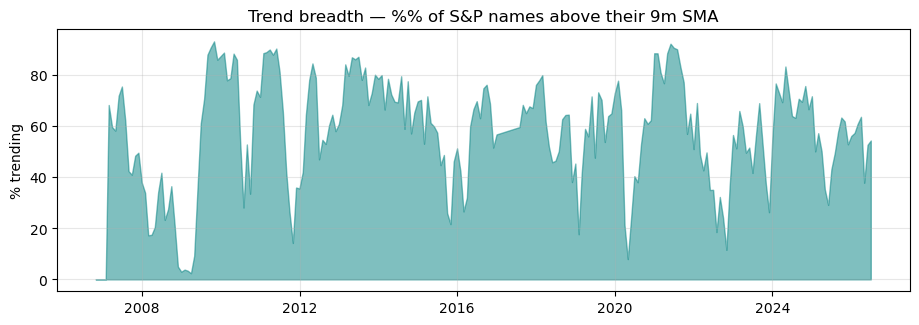

breadth: mean 57% | min 0% | max 93%


In [2]:
SMA_W, LOOKBACK = 9, 12     # base case: ~180-day SMA, 12-1 momentum
above = ms.trend_filter(md_m.prices, SMA_W, gap=1)
breadth = (above.sum(axis=1) / md_m.prices.notna().sum(axis=1)).rename("breadth")
breadth.to_csv(f"{RES}/figure_data/trend_breadth.csv")
fig, ax = plt.subplots(figsize=(11,3.4))
ax.fill_between(breadth.index, 100*breadth.values, color="teal", alpha=.5)
ax.set_title(f"Trend breadth — %% of S&P names above their {SMA_W}m SMA"); ax.set_ylabel("% trending"); ax.grid(alpha=.3)
fig.savefig(f"{RES}/figures/trend_breadth.png", dpi=120, bbox_inches="tight"); plt.show()
print("breadth: mean %.0f%% | min %.0f%% | max %.0f%%" % (100*breadth.mean(), 100*breadth.min(), 100*breadth.max()))

## 2. Information Coefficient — does the filter help the signal?

Compare the IC of plain risk-adjusted momentum vs **trend-filtered** momentum
(rank-IC of the signal vs the next month's return, computed among eligible names).

In [3]:
plain_cfg = ms.StrategyConfig(kind="xs", lookback=LOOKBACK, gap=1, top_pct=0.20, target_vol=0.20, max_leverage=1.0)
trend_cfg = ms.StrategyConfig(**{**plain_cfg.__dict__, "sma_window": SMA_W})
sig_plain, sig_trend = ms.build_signal(md_m, plain_cfg), ms.build_signal(md_m, trend_cfg)
ic = pd.DataFrame({nm: {k: ms.information_coefficient(s, md_m.returns)[k]
                        for k in ("mean_ic","ic_ir","t_stat","p_value","hit_rate","n_months")}
                   for nm, s in [("plain momentum", sig_plain), ("trend-filtered", sig_trend)]}).T
ic.to_csv(f"{RES}/figure_data/ic_comparison.csv")
print("IC: plain vs trend-filtered momentum (vs 1m forward return):"); display(ic)
print("\nTrend-filtered IC by horizon:"); display(ms.ic_by_horizon(sig_trend, md_m.returns).round(4))
print("avg eligible names: plain %.0f, trend-filtered %.0f" % (sig_plain.notna().sum(axis=1).mean(), sig_trend.notna().sum(axis=1).mean()))

IC: plain vs trend-filtered momentum (vs 1m forward return):


,mean_ic,ic_ir,t_stat,p_value,hit_rate,n_months
plain momentum,0.0152,0.0805,1.1888,0.2358,0.5459,218.0000
trend-filtered,0.0158,0.0925,1.3534,0.1774,0.5374,214.0000



Trend-filtered IC by horizon:


,horizon_m,mean_ic,ic_ir,t_stat,hit_rate,n_months
0,1,0.0158,0.0925,1.3534,0.5374,214
1,3,0.0125,0.0770,1.1214,0.5425,212
2,6,0.0106,0.0700,1.0118,0.5120,209
3,12,0.0070,0.0500,0.7121,0.5369,203


avg eligible names: plain 451, trend-filtered 265


## 3. Sensitivity — SMA window × momentum lookback

Both parameters vary, so sweep them: full-sample net Sharpe for each
(`sma_window`, `lookback`). The `none` row is plain momentum (no trend filter) as
the baseline.

Full-sample net Sharpe by (sma_window rows, lookback cols):


lookback,3,6,9,12
sma_window,,,,
none,0.2880,0.3420,0.4720,0.4580
6,0.3220,0.3310,0.3730,0.4100
9,0.2300,0.3030,0.3840,0.4040
12,0.2530,0.3450,0.4200,0.3880


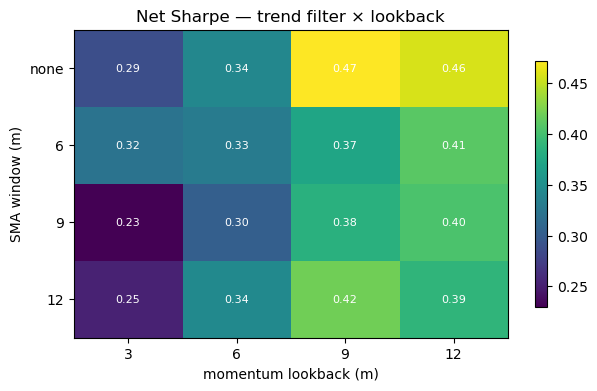

In [4]:
sma_grid = [None, 6, 9, 12]; lb_grid = [3, 6, 9, 12]
rows = {}
for sw in sma_grid:
    rows[sw if sw else "none"] = {}
    for lb in lb_grid:
        c = ms.StrategyConfig(kind="xs", lookback=lb, gap=1, sma_window=sw, top_pct=0.20, target_vol=0.20, max_leverage=1.0)
        rows[sw if sw else "none"][lb] = ms.metrics_from_result(bt.run(ms.build_signal(md_m, c), c))["Sharpe"]
sweep = pd.DataFrame(rows).T; sweep.index.name="sma_window"; sweep.columns.name="lookback"
sweep.to_csv(f"{RES}/figure_data/sma_lookback_sweep.csv")
print("Full-sample net Sharpe by (sma_window rows, lookback cols):"); display(sweep.round(3))
fig, ax = plt.subplots(figsize=(7,4))
im = ax.imshow(sweep.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(lb_grid))); ax.set_xticklabels(lb_grid); ax.set_yticks(range(len(sweep.index))); ax.set_yticklabels(sweep.index)
ax.set_xlabel("momentum lookback (m)"); ax.set_ylabel("SMA window (m)"); ax.set_title("Net Sharpe — trend filter × lookback")
for i in range(sweep.shape[0]):
    for j in range(sweep.shape[1]): ax.text(j,i,f"{sweep.values[i,j]:.2f}",ha="center",va="center",color="w",fontsize=8)
fig.colorbar(im, ax=ax, shrink=.8); fig.savefig(f"{RES}/figures/sma_lookback_sweep.png", dpi=120, bbox_inches="tight"); plt.show()

## 4. Strategy & sizing — equal vs signal weighting

Run the base trend-filtered strategy (`sma_window=9`, `lookback=12`) with **equal**
and **signal** weighting, against the plain-XS baseline. Full 2×3 dashboards saved.

In [5]:
variants = {
    "plain XS (equal)":   plain_cfg,
    "trend XS (equal)":   trend_cfg,
    "trend XS (signal)":  ms.StrategyConfig(**{**trend_cfg.__dict__, "weighting": "signal"}),
}
metrics = {}
for nm, c in variants.items():
    res = bt.run(ms.build_signal(md_m, c), c)
    metrics[nm] = ms.metrics_from_result(res)
tbl = pd.DataFrame(metrics).loc[["Sharpe","Sortino","CAGR","Ann.Vol","MaxDrawdown","Calmar","AnnTurnover","AnnTCost"]]
ms.save_metrics_table(metrics, f"{RES}/metrics/metrics.csv")
print("Trend-filtered momentum — equal vs signal, vs plain XS baseline:"); display(tbl.round(3))

Trend-filtered momentum — equal vs signal, vs plain XS baseline:


,plain XS (equal),trend XS (equal),trend XS (signal)
Sharpe,0.4580,0.4040,0.3870
Sortino,0.5940,0.5410,0.5320
CAGR,0.0580,0.0520,0.0500
Ann.Vol,0.1480,0.1560,0.1590
MaxDrawdown,-0.4740,-0.4560,-0.4530
Calmar,0.1230,0.1140,0.1100
AnnTurnover,2.9430,4.0180,3.9030
AnnTCost,0.0110,0.0150,0.0150


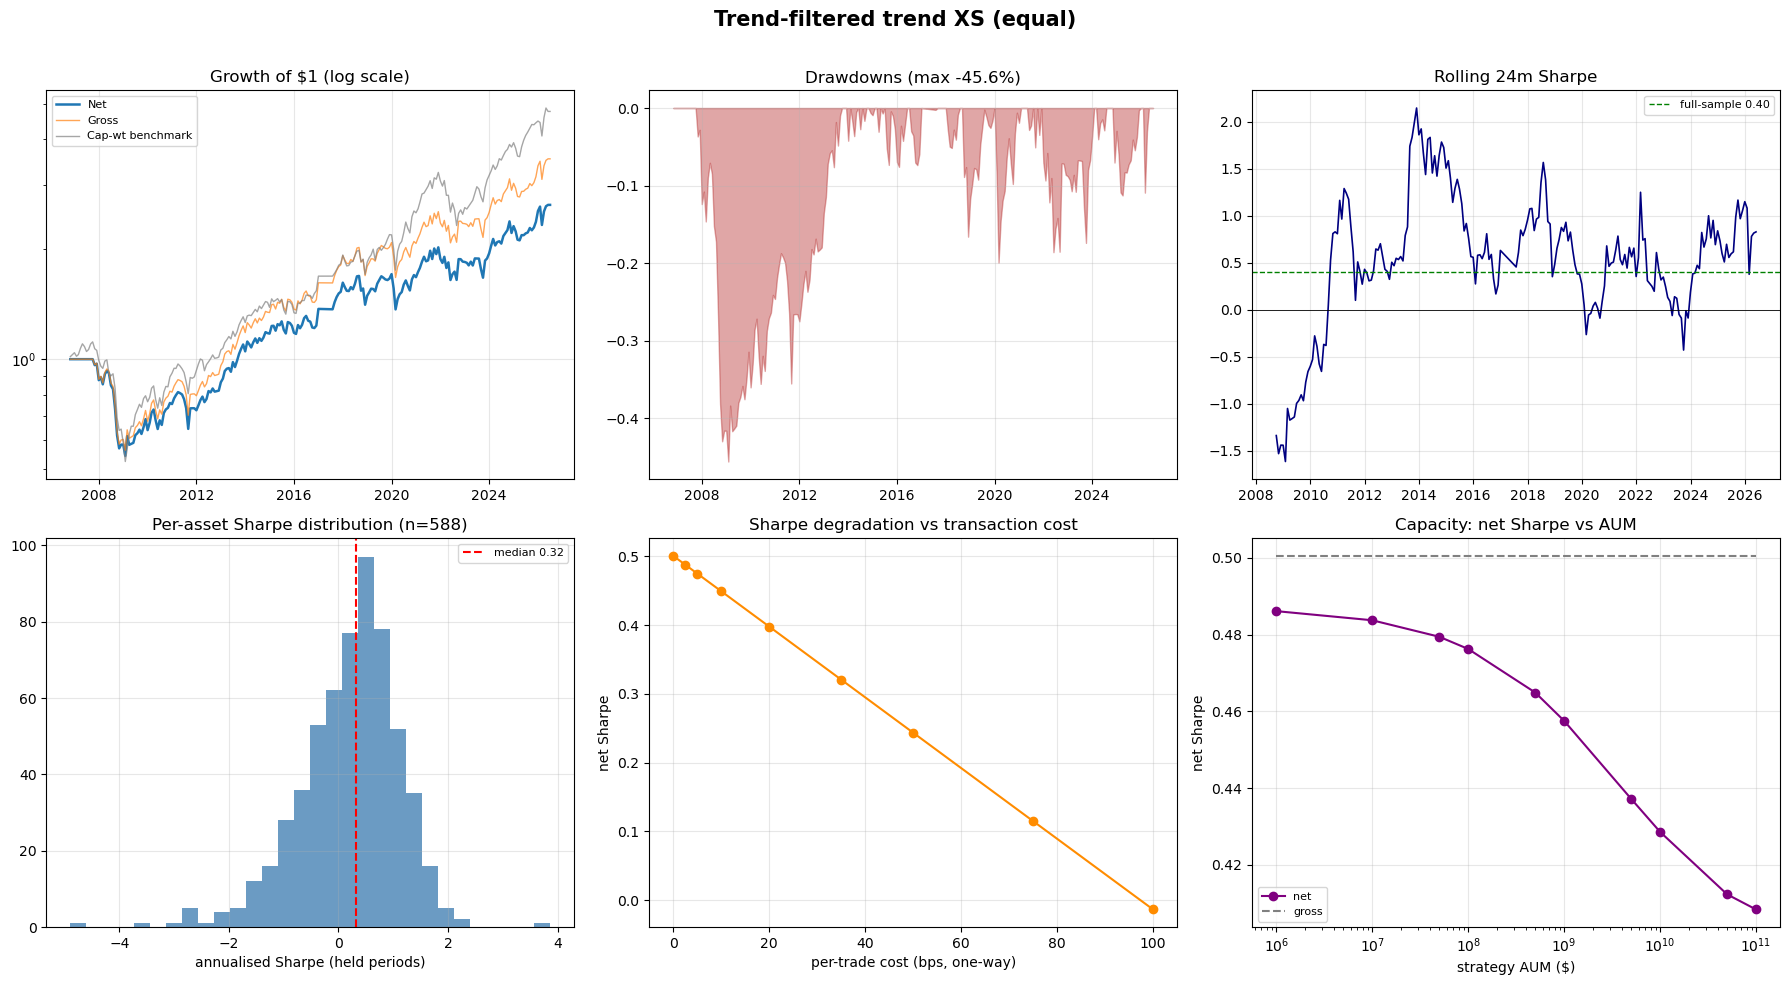

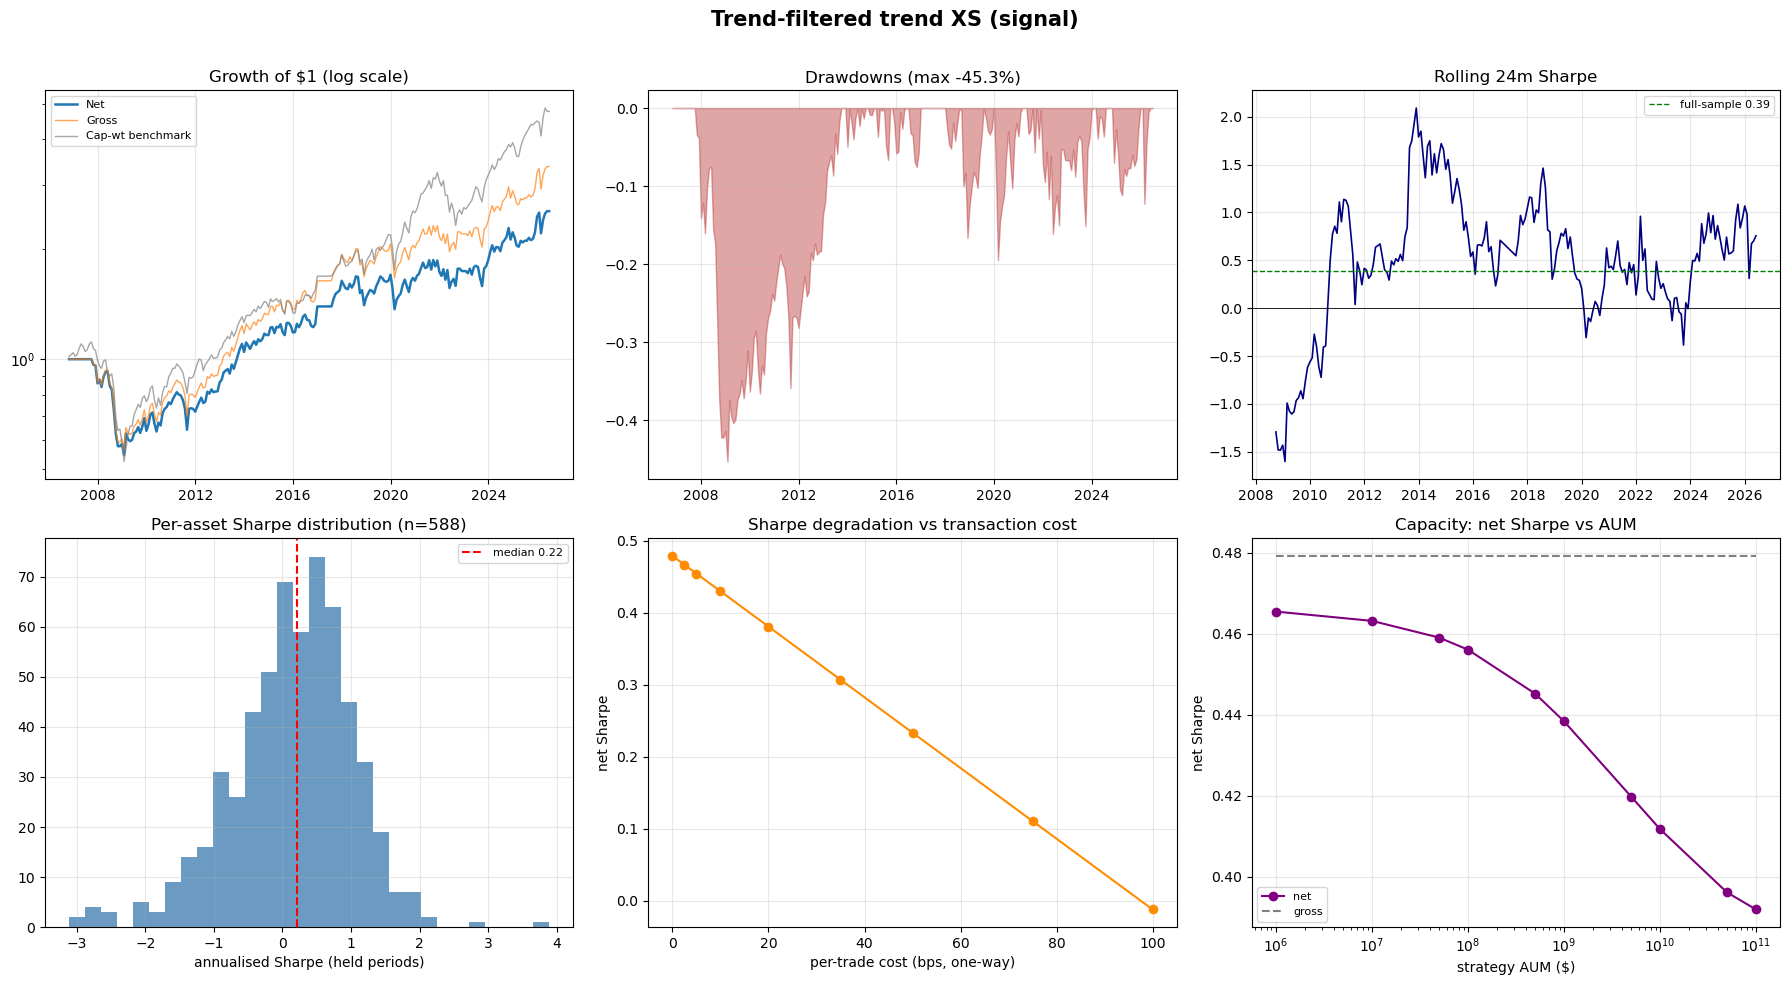

In [6]:
for nm, c, slug in [("trend XS (equal)", trend_cfg, "trend_xs_equal"),
                    ("trend XS (signal)", ms.StrategyConfig(**{**trend_cfg.__dict__,"weighting":"signal"}), "trend_xs_signal")]:
    res = bt.run(ms.build_signal(md_m, c), c)
    ms.save_weights(res, f"{RES}/weights/{slug}", sectors=md_m.sectors)
    ms.plot_strategy_dashboard(res, md_m, ms.build_signal(md_m, c), f"Trend-filtered {nm}",
                               fig_path=f"{RES}/figures/{slug}_dashboard.png", data_dir=f"{RES}/figure_data", slug=slug)
    plt.show()

## 5. Walk-forward validation

Optimise `lookback` and `sma_window` on a 60-month trailing window, apply to the
next 12 months, stitch the out-of-sample returns — for both weightings, vs the
plain-XS OOS baseline.

Walk-forward OOS (stitched):


,trend XS (equal),trend XS (signal),plain XS (equal)
Sharpe,0.7250,0.7010,0.6840
CAGR,0.0980,0.0970,0.0880
Ann.Vol,0.1440,0.1480,0.1370
MaxDrawdown,-0.1900,-0.1980,-0.2080
Calmar,0.5170,0.4890,0.4220


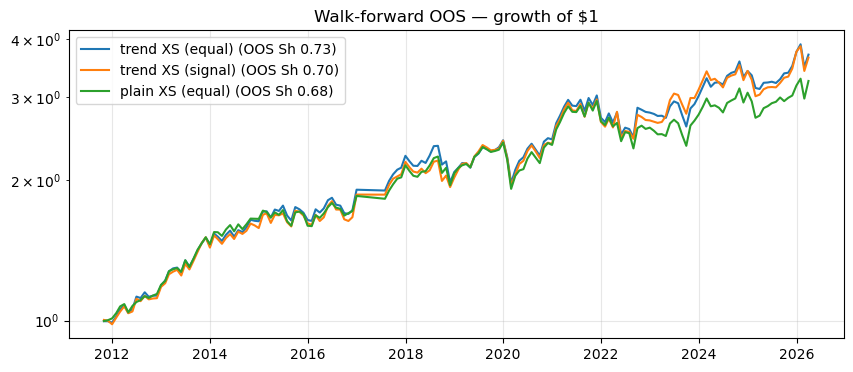

In [7]:
grid = {"lookback":[6,9,12], "sma_window":[6,9,12]}
wf = {}
wf["trend XS (equal)"]  = ms.WalkForwardValidator(bt, trend_cfg, grid, 60, 12).run()
wf["trend XS (signal)"] = ms.WalkForwardValidator(bt, ms.StrategyConfig(**{**trend_cfg.__dict__,"weighting":"signal"}), grid, 60, 12).run()
wf["plain XS (equal)"]  = ms.WalkForwardValidator(bt, plain_cfg, {"lookback":[6,9,12],"top_pct":[.1,.2,.3]}, 60, 12).run()
oos = pd.DataFrame({k: v.metrics() for k,v in wf.items()}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","Calmar"]]
print("Walk-forward OOS (stitched):"); display(oos.round(3))
fig, ax = plt.subplots(figsize=(10,4))
for k,v in wf.items():
    eq=(1+v.oos_returns.fillna(0)).cumprod(); ax.plot(eq.index, eq.values, label=f"{k} (OOS Sh {v.metrics()['Sharpe']:.2f})")
ax.set_yscale("log"); ax.set_title("Walk-forward OOS — growth of $1"); ax.legend(); ax.grid(alpha=.3)
wf["trend XS (equal)"].fold_table.to_csv(f"{RES}/figure_data/walkforward_folds_equal.csv", index=False)
fig.savefig(f"{RES}/figures/walkforward.png", dpi=120, bbox_inches="tight"); plt.show()

## 6. Weekly version (same strategy, weekly rebalance)

The identical trend-filtered XS strategy at **weekly** frequency (`periods_per_year=52`): SMA window ≈ **39 weeks** (≈9 months ≈ 180 trading days), momentum **52-4 weeks**. The scraper only has sub-monthly data from ~late-2022, so the weekly sample is **~2022-11→2026-06** — short, recent and momentum-friendly, so read as *indicative* (the walk-forward folds especially are data-limited).

weekly panel: 2022-11-11 -> 2026-06-19 (189 weeks) | trend breadth mean 50%


Weekly IC (plain vs trend-filtered):


,mean_ic,t_stat,hit_rate
plain (wk),0.0296,1.9166,0.5515
trend (wk),0.0403,3.1532,0.6250



Weekly trend-filtered — equal vs signal, vs plain (full weekly sample):


,trend wk (equal),trend wk (signal),plain wk (equal)
Sharpe,1.3020,1.4690,1.3250
CAGR,0.1700,0.2110,0.1540
Ann.Vol,0.1270,0.1370,0.1130
MaxDrawdown,-0.1460,-0.1380,-0.1380
Calmar,1.1650,1.5240,1.1160
AnnTurnover,6.9080,6.4910,4.6470


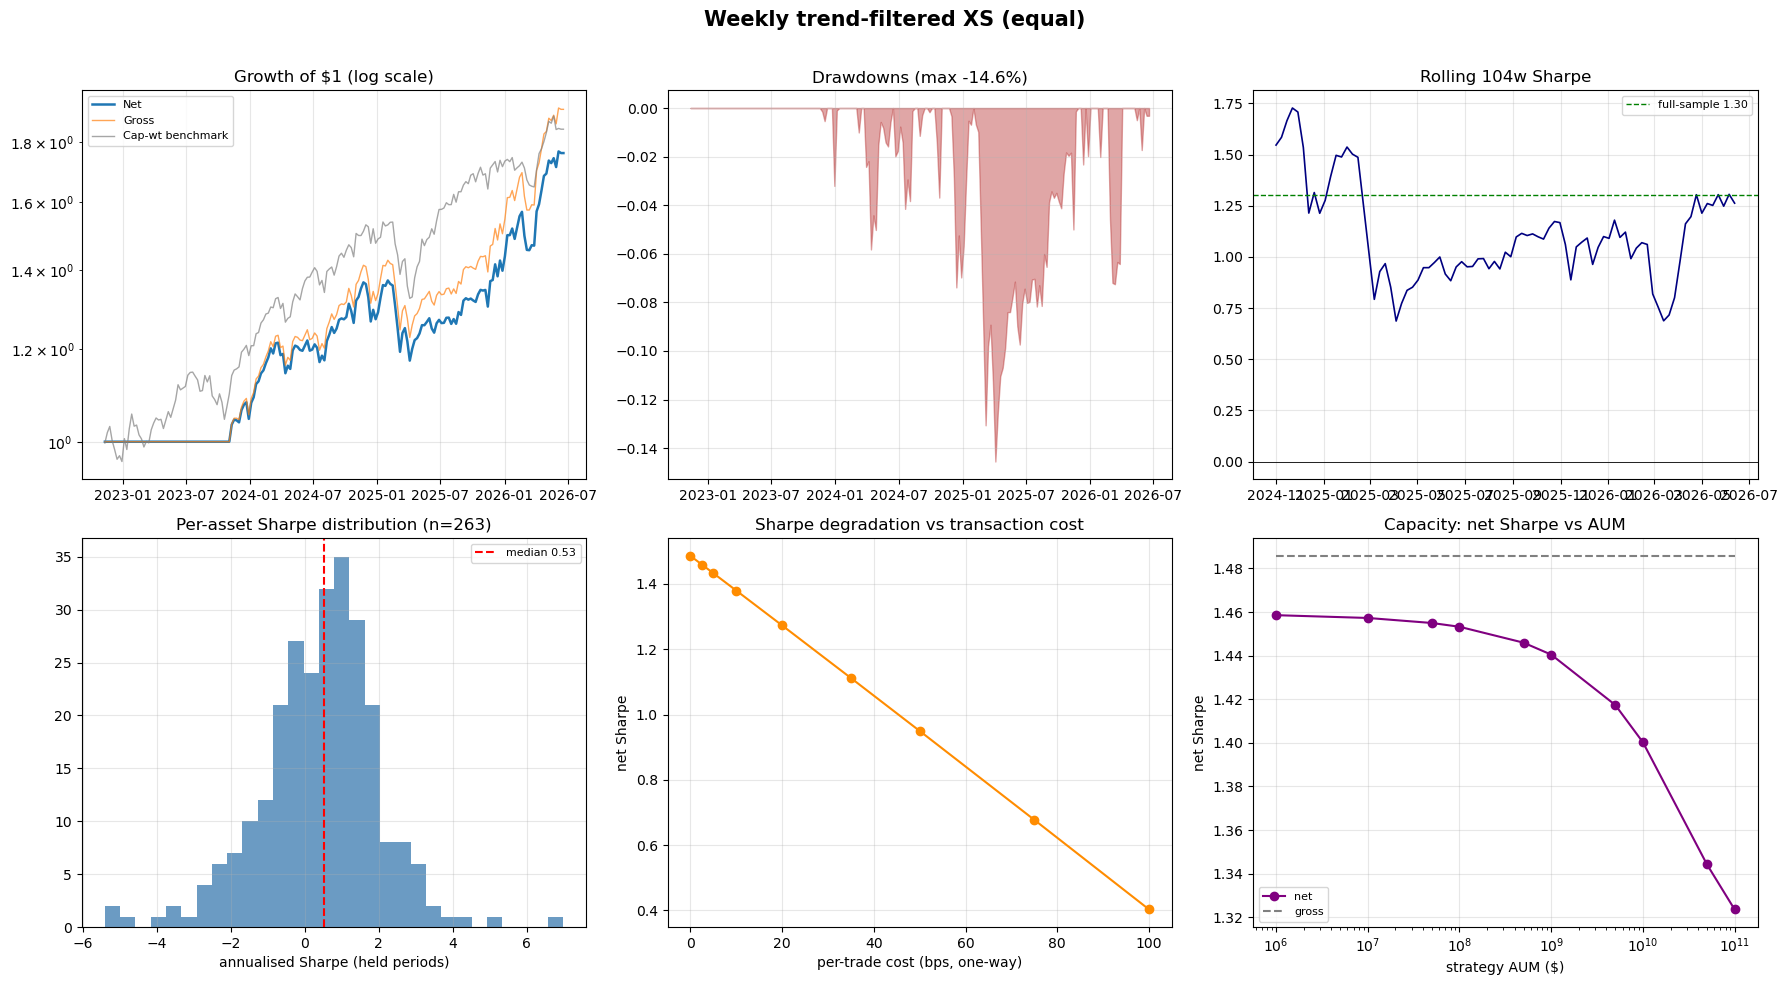

In [8]:
md_w = ms.DataLoader("data", freq="W").load()
btw = ms.Backtester(md_w, cost, periods_per_year=52)
SMA_Wk, LB_Wk, GAP_Wk = 39, 52, 4
wk_plain = ms.StrategyConfig(kind="xs", lookback=LB_Wk, gap=GAP_Wk, top_pct=0.20, vol_window=52,
                             target_vol=0.20, max_leverage=1.0, vol_lookback=26, vol_halflife=17.0)
wk_trend = ms.StrategyConfig(**{**wk_plain.__dict__, "sma_window": SMA_Wk})

bw = ms.trend_filter(md_w.prices, SMA_Wk, gap=GAP_Wk).sum(axis=1) / md_w.prices.notna().sum(axis=1)
print("weekly panel: %s -> %s (%d weeks) | trend breadth mean %.0f%%" % (
    md_w.summary()["start"], md_w.summary()["end"], md_w.summary()["n_months"], 100*bw.mean()))

ic_w = pd.DataFrame({nm: {k: ms.information_coefficient(ms.build_signal(md_w, c), md_w.returns)[k]
                          for k in ("mean_ic","t_stat","hit_rate")}
                     for nm, c in [("plain (wk)", wk_plain), ("trend (wk)", wk_trend)]}).T
print("Weekly IC (plain vs trend-filtered):"); display(ic_w.round(4))

mw = {}
for nm, c in [("trend wk (equal)", wk_trend),
              ("trend wk (signal)", ms.StrategyConfig(**{**wk_trend.__dict__, "weighting": "signal"})),
              ("plain wk (equal)", wk_plain)]:
    mw[nm] = ms.metrics_from_result(btw.run(ms.build_signal(md_w, c), c))
ms.save_metrics_table(mw, f"{RES}/metrics/weekly_metrics.csv")
print("\nWeekly trend-filtered — equal vs signal, vs plain (full weekly sample):")
display(pd.DataFrame(mw).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","Calmar","AnnTurnover"]].round(3))

res_w = btw.run(ms.build_signal(md_w, wk_trend), wk_trend)
ms.save_weights(res_w, f"{RES}/weights/weekly_trend_xs_equal", sectors=md_w.sectors)
ms.plot_strategy_dashboard(res_w, md_w, ms.build_signal(md_w, wk_trend), "Weekly trend-filtered XS (equal)",
    fig_path=f"{RES}/figures/weekly_trend_xs_equal_dashboard.png", data_dir=f"{RES}/figure_data", slug="weekly_trend_xs_equal")
plt.show()

In [9]:
# weekly walk-forward (short sample -> shorter windows; indicative only)
grid_w = {"lookback": [26, 52], "sma_window": [26, 39]}
wfw = {"trend wk (equal)":  ms.WalkForwardValidator(btw, wk_trend, grid_w, 52, 12).run(),
       "trend wk (signal)": ms.WalkForwardValidator(btw, ms.StrategyConfig(**{**wk_trend.__dict__,"weighting":"signal"}), grid_w, 52, 12).run()}
print("Weekly walk-forward OOS (indicative, short sample):")
display(pd.DataFrame({k: v.metrics() for k, v in wfw.items()}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown"]].round(3))

# same-window: weekly vs monthly trend-filtered (fair frequency comparison)
lo, hi = md_w.returns.index.min(), md_w.returns.index.max()
mth = ms.metrics_from_result(ms.Backtester(md_m, cost, 12).run(ms.build_signal(md_m, trend_cfg), trend_cfg, date_slice=(lo, hi)))
wk  = ms.metrics_from_result(btw.run(ms.build_signal(md_w, wk_trend), wk_trend))
cmp = pd.DataFrame({"monthly": mth, "weekly": wk}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","AnnTurnover"]]
cmp.to_csv(f"{RES}/figure_data/weekly_vs_monthly_trend.csv")
print("\nSame-window trend-filtered XS — monthly vs weekly (%s -> %s):" % (lo.date(), hi.date()))
display(cmp.round(3))

Weekly walk-forward OOS (indicative, short sample):


,trend wk (equal),trend wk (signal)
Sharpe,1.3010,1.5490
CAGR,0.1960,0.2570
Ann.Vol,0.1460,0.1560
MaxDrawdown,-0.1460,-0.1380



Same-window trend-filtered XS — monthly vs weekly (2022-11-11 -> 2026-06-19):


,monthly,weekly
Sharpe,0.7240,1.3020
CAGR,0.1000,0.1700
Ann.Vol,0.1470,0.1270
MaxDrawdown,-0.1140,-0.1460
AnnTurnover,4.0730,6.9080


## 7. Conclusions

* **Trend filter & IC.** Restricting to up-trending names modestly *raises* the
  momentum IC (t 1.19 → 1.35) and forces cash when breadth collapses (2008-09, 2020),
  trimming drawdowns — but it *concentrates* the book (~56 vs ~95 names), lifting vol
  and turnover (~4.0 vs ~2.9/yr).
* **Full sample (fixed params):** trend-filtering slightly *trails* plain XS
  (Sharpe ~0.40 vs ~0.46) at every SMA×lookback combo — the concentration cost
  outweighs the better selection.
* **Walk-forward OOS (adaptive params):** it **wins** — Sharpe **0.73 vs 0.68**,
  Calmar **0.52 vs 0.42**, max-DD **−19% vs −21%**. The trend filter's value is
  *drawdown / regime control*, which the OOS (post-2011, per-fold param selection)
  rewards more than the static full-sample run.
* **Sizing.** *Monthly*: equal ≥ signal (the edge is the selection). *Weekly*:
  signal-weighting **wins** (Sharpe 1.47 vs 1.30) — at higher frequency, tilting toward
  the strongest trenders paid off on the recent sample.
* **Weekly version (§6).** On the short 2022-11+ sample the trend filter is *more*
  effective: weekly IC jumps to **t≈3.2** (vs 1.9 plain), and weekly trend+signal
  reaches Sharpe ~1.47 / Calmar ~1.5 (vs plain 1.33) — but turnover is ~7×/yr and the
  window is a recent bull, so read as indicative.
* **Next step.** A breadth-scaled exposure (hold less when few names trend) would
  convert the filter more fully into de-risking. Caveats: monthly, price-return only,
  realistic costs, long-only no leverage; SMA in months (9m ≈ 180 trading days).